In [12]:
import pandas as pd
train_df = pd.read_parquet("./Data/train/train.parquet")

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [13]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Laptop GPU


In [14]:
train_df.head()

,level_2_id,gender,color,category_id,color_label,anonymous_id
0,932,NaN,Green,165,green,737d850c-c5f5-43bc-a4ef-b833cb0b866b
1,3356,NaN,Multicolore,54,multicolor,4b6913c9-46c6-4d6a-a1fd-19f9bf42e28d
2,435,NaN,White,75,white,5be2c43b-cbcc-40e7-a8b2-0620591ae628
3,6553,UNISEX,Black,152,black,ea01f5a8-3417-4de4-84d8-403870b318dd
4,443,NaN,Beige,82,beige,6c85a407-ef9a-42d3-ae4c-3c33b7851219


In [15]:
# 1. Shape
print(train_df.shape)

# 2. Null counts
print(train_df.isnull().sum())

# 3. Target distributions
print(train_df['category_id'].value_counts())
print(train_df['color_label'].value_counts())

# should print: 1    190  meaning every category_id maps to exactly one level_2_id

(31628, 6)
level_2_id          0
gender          25305
color            2582
category_id         0
color_label         0
anonymous_id        0
dtype: int64
category_id
68     188
81     188
33     187
138    187
28     187
      ... 
139    110
158     88
179     84
186     71
44       2
Name: count, Length: 191, dtype: int64
color_label
black         7022
white         3948
blue          2997
multicolor    2736
unknown       2725
gray          2527
brown         2253
red           2048
green         1740
pink          1721
yellow        1188
beige          723
Name: count, dtype: int64


In [16]:
print(train_df['gender'].value_counts())

# 4. Sanity check - doa category_id and level_2_id have a clean 1-to-1 mapping
print(train_df.groupby('category_id')['level_2_id'].nunique().value_counts())

gender
UNISEX    4021
FEMALE    1703
MALE       599
Name: count, dtype: int64
level_2_id
1    191
Name: count, dtype: int64


In [17]:
print(train_df['category_id'].value_counts()[train_df['category_id'].value_counts() < 50])

category_id
44    2
Name: count, dtype: int64


In [18]:
train_df[train_df['category_id']==44]

,level_2_id,gender,color,category_id,color_label,anonymous_id
844,2187,NaN,NaN,44,unknown,a093fd38-1b08-440b-b0a9-a84faa5a7293
28421,2187,NaN,NaN,44,unknown,ba507196-17e3-43a1-a340-8729af1170ce


In [19]:
import os

image_dir = "./Data/train/images"  

def image_exists(row):
    path = os.path.join(image_dir, str(row['category_id']), f"{row['anonymous_id']}.jpg")
    return os.path.exists(path)

train_df['image_exists'] = train_df.apply(image_exists, axis=1)

print(train_df['image_exists'].value_counts())
print(f"Missing images: {(~train_df['image_exists']).sum()}")

image_exists
True     31626
False        2
Name: count, dtype: int64
Missing images: 2


In [20]:
import json

with open("./Data/level2_categories.json", "r") as f:
    mapping = json.load(f)

taxonomy = pd.DataFrame(mapping)

# Rename to match your dataframe
taxonomy = taxonomy.rename(columns={"new_id": "category_id", "google_id": "level_2_id"})

print(taxonomy.head())
print(taxonomy.shape)  # should be 192 rows

   category_id  level_2_id                                   category_name
0            1        3237           Animals & Pet Supplies > Live Animals
1            2           2           Animals & Pet Supplies > Pet Supplies
2            3        1604                Apparel & Accessories > Clothing
3            4         167    Apparel & Accessories > Clothing Accessories
4            5         184  Apparel & Accessories > Costumes & Accessories
(192, 3)


In [21]:
df = train_df.merge(taxonomy[['category_id', 'category_name']], on='category_id', how='left')

# Sanity check
print(df[['category_id', 'category_name']].drop_duplicates().sort_values('category_id'))
print(f"Any missing names: {df['category_name'].isna().sum()}")

     category_id                                   category_name
304            1           Animals & Pet Supplies > Live Animals
410            2           Animals & Pet Supplies > Pet Supplies
193            3                Apparel & Accessories > Clothing
318            4    Apparel & Accessories > Clothing Accessories
337            5  Apparel & Accessories > Costumes & Accessories
..           ...                                             ...
891          188           Toys & Games > Outdoor Play Equipment
256          189                          Toys & Games > Puzzles
49           190                             Toys & Games > Toys
177          191  Vehicles & Parts > Vehicle Parts & Accessories
213          192                     Vehicles & Parts > Vehicles

[191 rows x 2 columns]
Any missing names: 0


In [22]:
df

,level_2_id,gender,color,category_id,color_label,anonymous_id,image_exists,category_name
0,932,NaN,Green,165,green,737d850c-c5f5-43bc-a4ef-b833cb0b866b,True,Office Supplies > General Office Supplies
1,3356,NaN,Multicolore,54,multicolor,4b6913c9-46c6-4d6a-a1fd-19f9bf42e28d,True,Electronics > Arcade Equipment
2,435,NaN,White,75,white,5be2c43b-cbcc-40e7-a8b2-0620591ae628,True,"Food, Beverages & Tobacco > Tobacco Products"
3,6553,UNISEX,Black,152,black,ea01f5a8-3417-4de4-84d8-403870b318dd,True,Luggage & Bags > Train Cases
4,443,NaN,Beige,82,beige,6c85a407-ef9a-42d3-ae4c-3c33b7851219,True,Furniture > Chairs
...,...,...,...,...,...,...,...,...
31623,2636,NaN,Nero,175,black,7dadb4da-8999-49ff-89b4-01e1c56aeabd,True,Office Supplies > Shipping Supplies
31624,499982,NaN,Red,112,red,98d3f9fa-cecd-4414-9470-8aeddcd165c8,True,Hardware > Small Engines
31625,3650,NaN,White,114,white,1f19012e-89cb-4999-977c-780771e363e0,True,Hardware > Tool Accessories
31626,7261,NaN,Grau,27,gray,3e517d3e-4dd1-4ebb-b0e3-3e9c461afd1b,True,Business & Industrial > Automation Control Com...


In [23]:
#split category_name into category and subcategory
df[['category', 'subcategory']] = df['category_name'].str.split(' > ', expand=True)

In [24]:
df

,level_2_id,gender,color,category_id,color_label,anonymous_id,image_exists,category_name,category,subcategory
0,932,NaN,Green,165,green,737d850c-c5f5-43bc-a4ef-b833cb0b866b,True,Office Supplies > General Office Supplies,Office Supplies,General Office Supplies
1,3356,NaN,Multicolore,54,multicolor,4b6913c9-46c6-4d6a-a1fd-19f9bf42e28d,True,Electronics > Arcade Equipment,Electronics,Arcade Equipment
2,435,NaN,White,75,white,5be2c43b-cbcc-40e7-a8b2-0620591ae628,True,"Food, Beverages & Tobacco > Tobacco Products","Food, Beverages & Tobacco",Tobacco Products
3,6553,UNISEX,Black,152,black,ea01f5a8-3417-4de4-84d8-403870b318dd,True,Luggage & Bags > Train Cases,Luggage & Bags,Train Cases
4,443,NaN,Beige,82,beige,6c85a407-ef9a-42d3-ae4c-3c33b7851219,True,Furniture > Chairs,Furniture,Chairs
...,...,...,...,...,...,...,...,...,...,...
31623,2636,NaN,Nero,175,black,7dadb4da-8999-49ff-89b4-01e1c56aeabd,True,Office Supplies > Shipping Supplies,Office Supplies,Shipping Supplies
31624,499982,NaN,Red,112,red,98d3f9fa-cecd-4414-9470-8aeddcd165c8,True,Hardware > Small Engines,Hardware,Small Engines
31625,3650,NaN,White,114,white,1f19012e-89cb-4999-977c-780771e363e0,True,Hardware > Tool Accessories,Hardware,Tool Accessories
31626,7261,NaN,Grau,27,gray,3e517d3e-4dd1-4ebb-b0e3-3e9c461afd1b,True,Business & Industrial > Automation Control Com...,Business & Industrial,Automation Control Components


In [25]:
from sklearn.preprocessing import LabelEncoder
import pickle

# Encode color
color_encoder = LabelEncoder()
df['color_encoded'] = color_encoder.fit_transform(df['color_label'])

# Encode gender - fill nulls first
df['gender_filled'] = df['gender'].fillna('UNKNOWN')
gender_encoder = LabelEncoder()
df['gender_encoded'] = gender_encoder.fit_transform(df['gender_filled'])

# Encode category
cat_encoder = LabelEncoder()
df['category_encoded'] = cat_encoder.fit_transform(df['category_id'])

# Check
print(dict(zip(color_encoder.classes_, color_encoder.transform(color_encoder.classes_))))
print(dict(zip(gender_encoder.classes_, gender_encoder.transform(gender_encoder.classes_))))
print(f"Min category encoded: {df['category_encoded'].min()}")
print(f"Max category encoded: {df['category_encoded'].max()}")
print(f"Unique categories: {df['category_encoded'].nunique()}")

# Save encoders
with open("color_encoder.pkl", "wb") as f:
    pickle.dump(color_encoder, f)

with open("gender_encoder.pkl", "wb") as f:
    pickle.dump(gender_encoder, f)

with open("category_encoder.pkl", "wb") as f:
    pickle.dump(cat_encoder, f)

KeyboardInterrupt: 

In [ ]:
# Separate class 44
from sklearn.model_selection import train_test_split

class_44 = df[df['category_id'] == 44].reset_index(drop=True)
train_44 = class_44.iloc[[0]]
test_44  = class_44.iloc[[1]]

# Stratified split on the rest
df_without_44 = df[df['category_id'] != 44]
train_df, test_df = train_test_split(df_without_44, test_size=0.2, stratify=df_without_44['category_id'], random_state=42)

# Add class 44 manually
train_df = pd.concat([train_df, train_44]).reset_index(drop=True)
test_df  = pd.concat([test_df,  test_44]).reset_index(drop=True)

print(f"Train size: {len(train_df)} | Classes: {train_df['category_id'].nunique()}")
print(f"Test size:  {len(test_df)}  | Classes: {test_df['category_id'].nunique()}")

Train size: 25301 | Classes: 191
Test size:  6327  | Classes: 191


In [ ]:
print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")

# Make sure all 190 classes are in the train set
print(f"Classes in train: {train_df['category_id'].nunique()}")
print(f"Classes in test:  {test_df['category_id'].nunique()}")

Train size: 25301
Test size:  6327
Classes in train: 191
Classes in test:  191


In [ ]:
train_df.head()

,level_2_id,gender,color,category_id,color_label,anonymous_id,image_exists,category_name,category,subcategory,color_encoded,gender_filled,gender_encoded,category_encoded
0,976,NaN,Black,48,black,d8c0e674-9a7d-4198-b781-aefb9a32ba32,True,Business & Industrial > Signage,Business & Industrial,Signage,1,UNKNOWN,3,47
1,499982,NaN,NaN,112,unknown,104571a2-a912-4bbf-9393-9e3e4dabb775,True,Hardware > Small Engines,Hardware,Small Engines,9,UNKNOWN,3,110
2,2862,NaN,Gray,123,gray,37f21658-87ea-4cac-a652-b728055f89a6,True,Home & Garden > Fireplace & Wood Stove Accesso...,Home & Garden,Fireplace & Wood Stove Accessories,4,UNKNOWN,3,121
3,2496,MALE,Black,43,black,cd97d000-3694-4abf-8c5a-9b6963202c7b,True,Business & Industrial > Medical,Business & Industrial,Medical,1,MALE,1,42
4,114,NaN,jaune,28,yellow,692c024a-89b7-48ec-940c-354f7f9905d1,True,Business & Industrial > Construction,Business & Industrial,Construction,11,UNKNOWN,3,27


In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class ProductDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        img_path = os.path.join(self.image_dir, str(row['category_id']), f"{row['anonymous_id']}.jpg")
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        category = int(row['category_encoded'])  
        color    = int(row['color_encoded'])
        gender   = int(row['gender_encoded'])
        
        return image, category, color, gender

image_dir = r"C:\Users\karim\Desktop\Data Science Projects\Criteo Image Classification\Data\train\images"

train_dataset = ProductDataset(train_df, image_dir, transform=train_transforms)
test_dataset  = ProductDataset(test_df,  image_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

images, categories, colors, genders = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Category labels:   {categories.shape}")
print(f"Color labels:      {colors.shape}")
print(f"Gender labels:     {genders.shape}")
print(f"Category min: {categories.min()} | max: {categories.max()}")  # should be 0-190

Image batch shape: torch.Size([32, 3, 224, 224])
Category labels:   torch.Size([32])
Color labels:      torch.Size([32])
Gender labels:     torch.Size([32])
Category min: 3 | max: 186


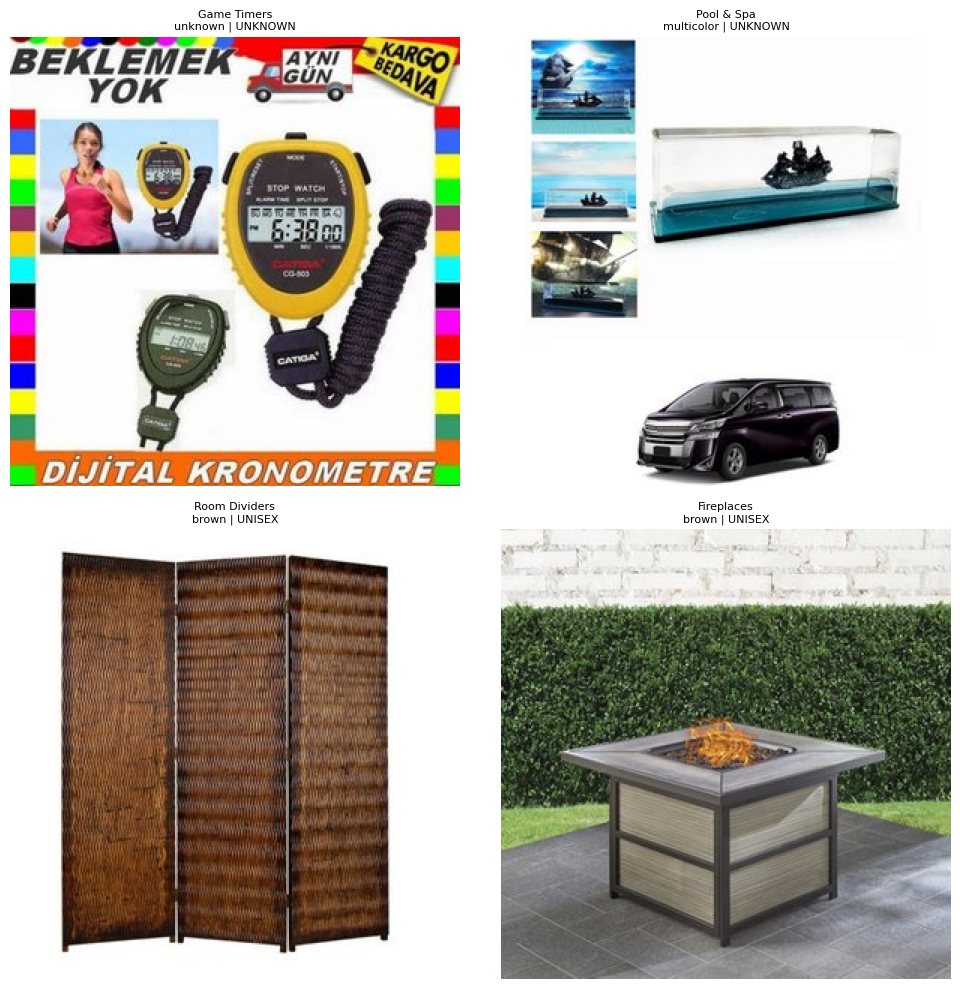

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples(df, image_dir, n=4):
    sample = df.sample(n).reset_index(drop=True)
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    
    for i, ax in enumerate(axes.flat):
        row = sample.iloc[i]
        img_path = os.path.join(image_dir, str(row['category_id']), f"{row['anonymous_id']}.jpg")
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f"{row['subcategory']}\n{row['color_label']} | {row['gender_filled']}", fontsize=8)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

show_samples(train_df, image_dir)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

NUM_CLASSES_CATEGORY = 191

vit = models.vit_b_16(weights="IMAGENET1K_V1")
vit.heads = nn.Identity()

class ViTCategory(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.dropout = nn.Dropout(0.3)
        self.category_head = nn.Linear(768, NUM_CLASSES_CATEGORY)

    def forward(self, x):
        features = self.dropout(self.backbone(x))
        return self.category_head(features)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViTCategory(vit).to(device)
print(device)

cuda


In [ ]:
#Iteration

criterion = nn.CrossEntropyLoss()

# Phase 1
for param in model.backbone.parameters():
    param.requires_grad = False

optimizer = Adam(model.category_head.parameters(), lr=1e-3)

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct = 0, 0

    for images, categories, colors, genders in loader:
        images     = images.to(device)
        categories = categories.to(device)

        optimizer.zero_grad()
        cat_out = model(images)

        loss = criterion(cat_out, categories)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (cat_out.argmax(1) == categories).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

# Phase 1 - 5 epochs
print("Phase 1 - heads only")
for epoch in range(3):
    loss, acc = train_epoch(model, train_loader, optimizer)
    print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Category Acc: {acc:.4f}")

# Phase 2 - unfreeze with weight decay and lower LR
print("Phase 2 - full fine-tuning")
for param in model.backbone.parameters():
    param.requires_grad = True

optimizer = Adam([
    {'params': model.backbone.parameters(),      'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.category_head.parameters(), 'lr': 1e-4, 'weight_decay': 1e-4},
])

best_acc = 0
for epoch in range(3):
    loss, acc = train_epoch(model, train_loader, optimizer)
    print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Category Acc: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "vit_category_best.pth")
        print(f"  → Saved new best model")

Phase 1 - heads only
Epoch 1 | Loss: 3.6481 | Category Acc: 0.2641
Epoch 2 | Loss: 2.8184 | Category Acc: 0.3928
Epoch 3 | Loss: 2.5864 | Category Acc: 0.4244
Phase 2 - full fine-tuning
Epoch 1 | Loss: 2.2295 | Category Acc: 0.4881
  → Saved new best model
Epoch 2 | Loss: 1.9682 | Category Acc: 0.5422
  → Saved new best model
Epoch 3 | Loss: 1.7688 | Category Acc: 0.5886
  → Saved new best model


In [ ]:
from sklearn.metrics import f1_score)


print("\n--- Evaluating on test set ---")
model.load_state_dict(torch.load("vit_category_best.pth"))
model.eval()

correct   = 0
total     = len(test_loader.dataset)
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, categories, colors, genders in test_loader:
        images     = images.to(device)
        categories = categories.to(device)
        cat_out    = model(images)
        
        preds = cat_out.argmax(1)
        correct += (preds == categories).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(categories.cpu().numpy())

print(f"Test Category Accuracy: {correct/total:.4f}")
print(f"Best Train Accuracy:    {best_acc:.4f}")
print(f"Overfitting gap:        {best_acc - correct/total:.4f}")
print(f"F1 Macro:               {f1_score(all_labels, all_preds, average='macro'):.4f}")
print(f"F1 Weighted:            {f1_score(all_labels, all_preds, average='weighted'):.4f}")
print("\nDone.")

NameError: name 'ViTCategory' is not defined